<a href="https://colab.research.google.com/github/sowmyasameer4/ML-DL-Projects/blob/main/Student_Performance/PROJECT(2)(StudentPerformance).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem statement
Educational institutions struggle to identify students who are at risk of poor academic performance early. This project predicts student performance using historical academic and behavioural data to support timely intervention

Project title-
AI Based Student Performance Prediction System

Problem statement-
Educational institutions struggle to identify students who are at risk of poor academic performance early. This project predicts student performance using historical academic and behavioural data to support timely intervention.

Objective-
To build a machine learning model that predicts whether a student will perform well or poorly based on multiple factors and provide insights for improvement.

Dataset-
Student academic dataset containing
Attendance percentage
Internal assessment marks
Previous semester grades
Study hours
Participation in activities
Socio economic indicators
You can use a public dataset or create a realistic one.

Technologies used-
Python
Pandas
NumPy
Matplotlib and Seaborn
Scikit learn
Jupyter Notebook.


##  **Column Name**               - **Description**                                                                                                                                                     

- **Attendance_Percentage**     - Percentage of classes attended by the student during the semester (range: 40–100). Higher attendance generally indicates better engagement and academic discipline.
- **Internal_Assessment_Marks** - Marks obtained in internal assessments such as quizzes, assignments, and mid-term exams (range: 30–100). Reflects continuous academic performance.                  
- **Previous_Sem_Grade**        - Grade obtained in the previous semester (A, B, C, D, E, F). Acts as a strong indicator of past academic consistency.                                                
- **Study_Hours_Per_Week**      - Average number of hours the student spends studying per week (range: 1–19). Higher study hours usually correlate with better performance.                           
- **Activity_Participation**    - Indicates whether the student actively participates in extracurricular or co-curricular activities (Yes/No). Helps assess overall engagement and time management.   
- **Socio_Economic_Status**     - Economic background of the student categorized as Low, Medium, or High. This may influence access to educational resources.                                         
- **Performance**               - **Target variable** indicating overall student performance: **1 = Good performance**, **0 = Poor performance**. Derived based on academic and behavioral factors.   
- **Technologies Used**


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Datasets/dataset_with_technology_used.csv")
df

,Attendance_Percentage,Internal_Assessment_Marks,Previous_Sem_Grade,Study_Hours_Per_Week,Activity_Participation,Socio_Economic_Status,Performance,technology_used
0,78,87,B,7,Yes,Low,0,pandas
1,91,41,A,18,Yes,Low,0,jupyter notebook
2,68,42,C,4,No,Medium,0,python
3,54,41,C,4,No,High,0,pandas
4,82,67,B,1,No,High,0,numpy
...,...,...,...,...,...,...,...,...
99995,94,50,A,15,No,Medium,0,scikit learn
99996,46,32,B,14,Yes,Medium,0,jupyter notebook
99997,91,52,E,9,Yes,Medium,0,scikit learn
99998,82,53,A,17,No,Low,0,python


In [ ]:
# Specify axis=1 to drop a column; use inplace=True to modify the original dataframe
df.drop("technology_used", axis=1, inplace=True)
df.head()

,Attendance_Percentage,Internal_Assessment_Marks,Previous_Sem_Grade,Study_Hours_Per_Week,Activity_Participation,Socio_Economic_Status,Performance
0,78,87,B,7,Yes,Low,0
1,91,41,A,18,Yes,Low,0
2,68,42,C,4,No,Medium,0
3,54,41,C,4,No,High,0
4,82,67,B,1,No,High,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column                     Non-Null Count   Dtype 
---  ------                     --------------   ----- 
 0   Attendance_Percentage      100000 non-null  int64 
 1   Internal_Assessment_Marks  100000 non-null  int64 
 2   Previous_Sem_Grade         100000 non-null  object
 3   Study_Hours_Per_Week       100000 non-null  int64 
 4   Activity_Participation     100000 non-null  object
 5   Socio_Economic_Status      100000 non-null  object
 6   Performance                100000 non-null  int64 
dtypes: int64(4), object(3)
memory usage: 5.3+ MB


In [ ]:
df.isnull().sum()

,0
Attendance_Percentage,0
Internal_Assessment_Marks,0
Previous_Sem_Grade,0
Study_Hours_Per_Week,0
Activity_Participation,0
Socio_Economic_Status,0
Performance,0


## Visualization

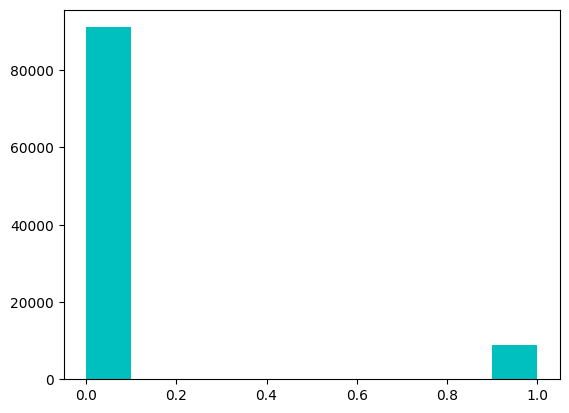

In [ ]:
plt.hist(df["Performance"],color='c')
plt.show()

<Figure size 3000x1800 with 0 Axes>

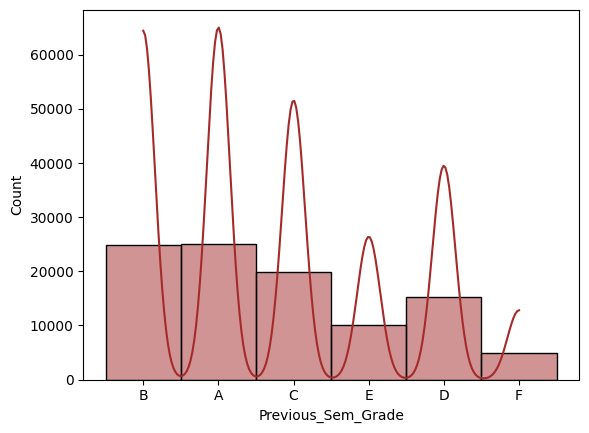

<Figure size 3000x1800 with 0 Axes>

In [ ]:
sns.histplot(df["Previous_Sem_Grade"],color='brown',bins=30,kde=True)
plt.figure(figsize=(30,18))

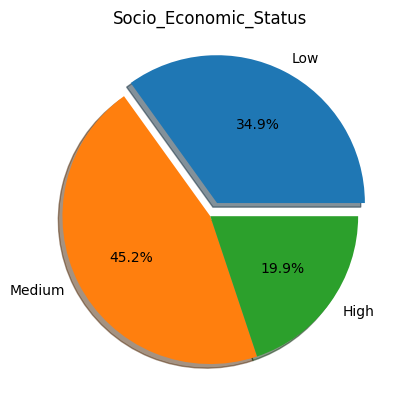

In [ ]:
mylabels = ["Low","Medium","High"]
myexplode = [0.1,0,0]
# Get the counts for each category to provide the 'x' argument
counts = df["Socio_Economic_Status"].value_counts().reindex(mylabels)

plt.pie(counts, labels=mylabels, explode=myexplode, shadow=True, autopct='%1.1f%%')
plt.title("Socio_Economic_Status")
plt.show()

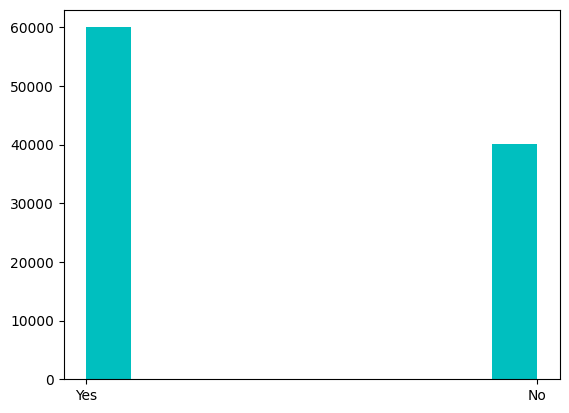

In [ ]:
plt.hist(df["Activity_Participation"],color='c')
plt.show()

## Cleaning Datas

In [ ]:
df["Previous_Sem_Grade"].unique()

array(['B', 'A', 'C', 'E', 'D', 'F'], dtype=object)

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df['Previous_Sem_Grade'] = le.fit_transform(df['Previous_Sem_Grade'])

In [ ]:
df["Activity_Participation"].unique()

array(['Yes', 'No'], dtype=object)

In [ ]:
df['Activity_Participation'] = le.fit_transform(df['Activity_Participation'])

In [ ]:
df["Socio_Economic_Status"].unique()

array(['Low', 'Medium', 'High'], dtype=object)

In [ ]:
df["Socio_Economic_Status"].replace(["Low", "Medium", "High"], [0, 1, 2], inplace=True)

/tmp/ipython-input-1022599298.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Socio_Economic_Status"].replace(["Low", "Medium", "High"], [0, 1, 2], inplace=True)
/tmp/ipython-input-1022599298.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Socio_Economic_Status"].replace(["Low", "Med

## Correlation

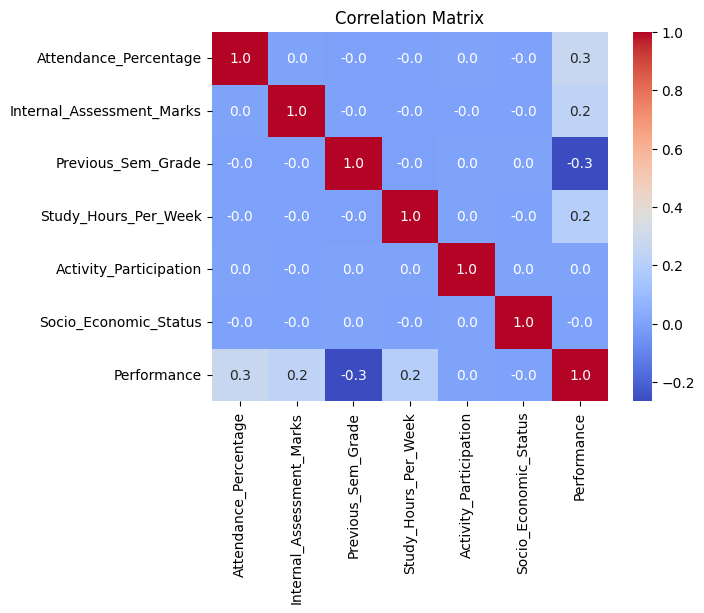

In [ ]:
# plt.figure(figsize=(20,15))
corr_matrix = df.corr()

sns.heatmap(corr_matrix, annot=True, fmt='0.01f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

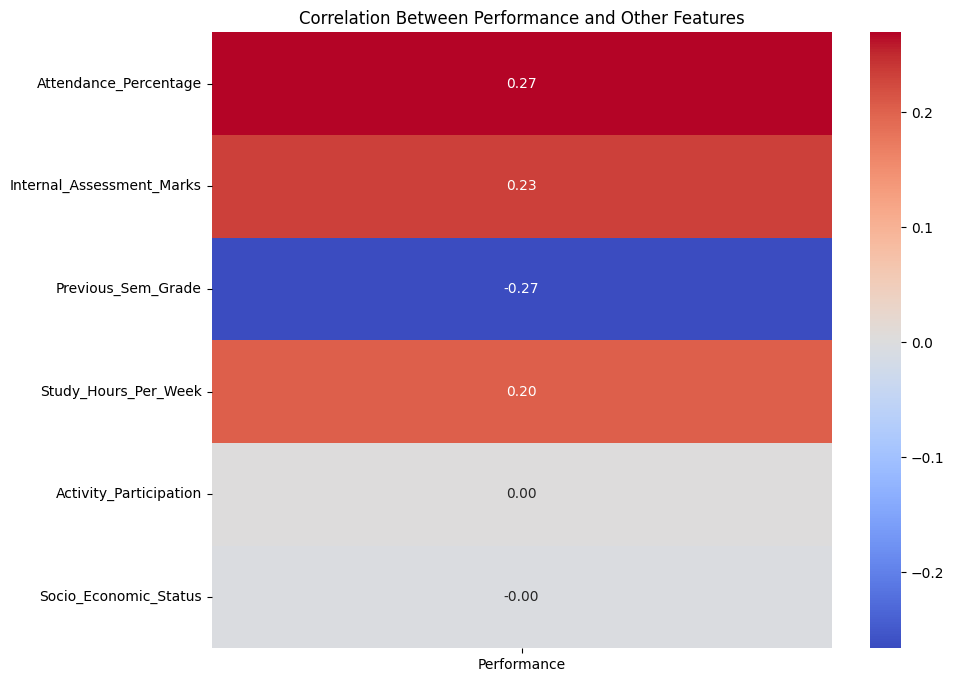

In [ ]:
plt.figure(figsize=(10,8))
HadHeartAttack_corr = df.corr()['Performance']

HadHeartAttack_corr = HadHeartAttack_corr.drop('Performance')

sns.heatmap(HadHeartAttack_corr.to_frame(), annot=True, fmt='.2f', cmap='coolwarm',
            cbar=True, annot_kws={'size': 10})
plt.title('Correlation Between Performance and Other Features')
plt.show()

In [ ]:
df.drop(["Activity_Participation","Socio_Economic_Status"],axis=1, inplace=True)

## Checking Outliers

<Axes: >

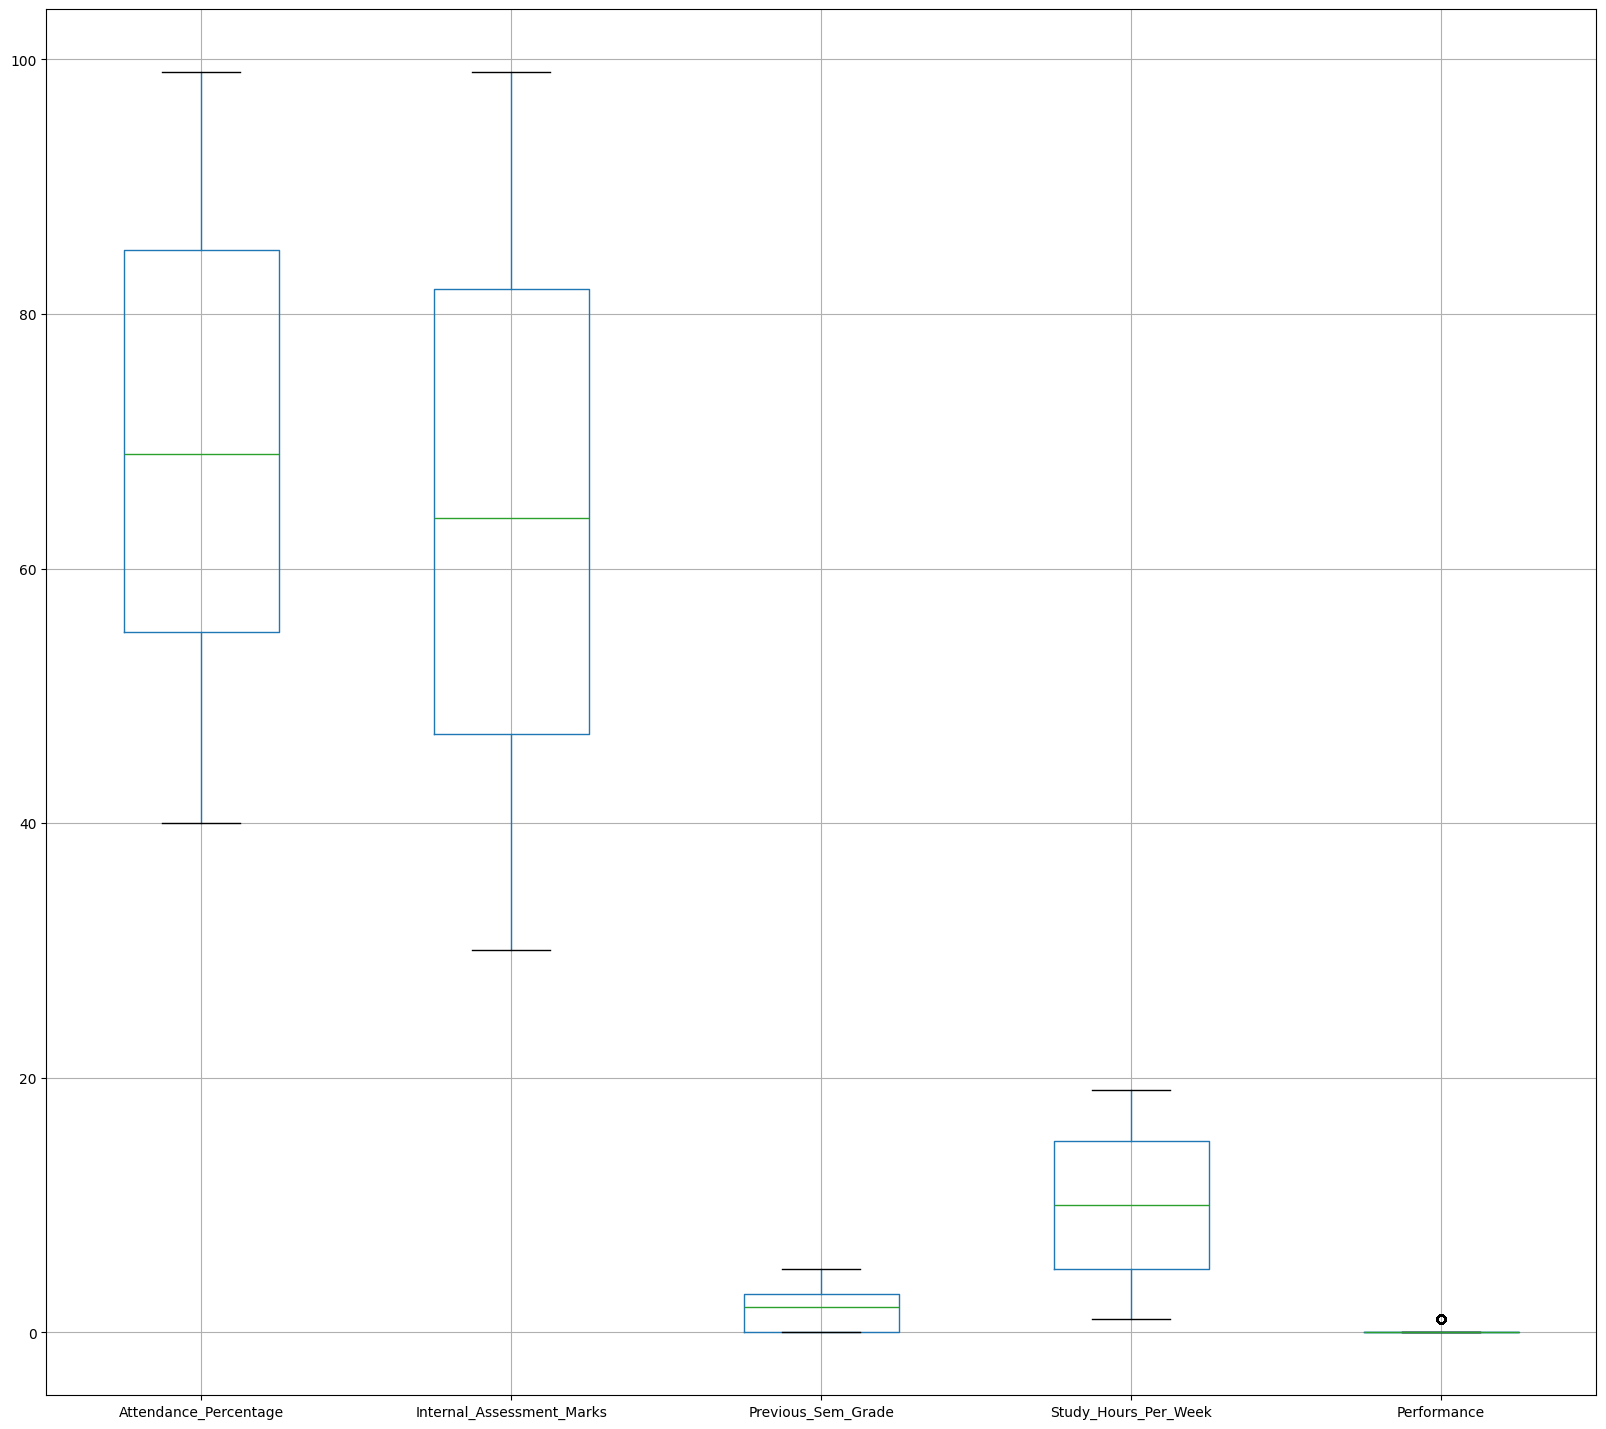

In [ ]:
df.boxplot(figsize=(20,18))

In [ ]:
def remove_outliers_iqr(df, exclude_column):
  for col in df.columns:
    if col ==exclude_column:
      continue

    Q1 = df[col].quantile(.25)
    Q3 = df[col].quantile(.75)
    IQR =Q3-Q1
    lower_bound = Q1-1.5*IQR
    upper_bound = Q3+1.5*IQR

    df = df[(df[col] >= lower_bound) & (df[col] <=upper_bound)]
  return df

df_cleaned = remove_outliers_iqr(df, exclude_column='Performance')
df = df_cleaned


## Scaling

In [ ]:
from sklearn.preprocessing import MinMaxScaler

features = ['Attendance_Percentage','Internal_Assessment_Marks','Previous_Sem_Grade','Study_Hours_Per_Week']

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df[features])

scaled_df =pd.DataFrame(scaled_data, columns = features)

## checking Accuracy

### Logistic Regression

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

x = df[['Attendance_Percentage','Internal_Assessment_Marks','Previous_Sem_Grade','Study_Hours_Per_Week']]
y = df['Performance'] #Target variable

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

model = LogisticRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline Model accuracy: {accuracy:.2f}')

Baseline Model accuracy: 0.94


### Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

x = df[['Attendance_Percentage','Internal_Assessment_Marks','Previous_Sem_Grade','Study_Hours_Per_Week']]
y = df['Performance'] #Target variable

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

model = DecisionTreeClassifier()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline Model accuracy: {accuracy:.2f}')

Baseline Model accuracy: 1.00


In [ ]:
import pickle
with open("DeisionTree_Model.pkl","wb")as file:
  pickle.dump(model,file)

# Conclusion

In this project, the dataset used to build and evaluate classification models. Two machine learning algorithms were implemented:


*   Logistic Regression
*   Decision Tree


After training and evaluating both models, the Decision Tree classifier achieved the highest accuracy of 100% (accuracy = 1.0), outperforming Logistic Regression. This indicates that the Decision Tree model was able to capture the patterns and relationships in the dataset more effectively.The final trained model was saved using Pickle format, which allows the model to be reused later without retraining. This makes the model deployment-ready and suitable for integration into applications